In [1]:
import os, sys
sys.path.append("..")

import matplotlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

import numpy as np
import torch
import torch.nn as nn
import torchvision
import gc

from src import distributions
import torch.nn.functional as F

from src.resnet2 import ResNet_D
from src.unet import UNet

from src.tools import unfreeze, freeze
from src.tools import weights_init_D, weights_init_mlp
from src.tools import load_dataset, get_Z_pushed_loader_stats
from src.fid_score import calculate_frechet_distance
from src.plotters import plot_random_Z_images, plot_Z_images

from copy import deepcopy
import json

from tqdm import tqdm_notebook as tqdm
from IPython.display import clear_output

import wandb # <--- online logging of the results
from src.tools import fig2data, fig2img # for wandb

# This needed to use dataloaders for some datasets
from PIL import PngImagePlugin

API_key = "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"
wandb.login(key = API_key)

LARGE_ENOUGH_NUMBER = 100
PngImagePlugin.MAX_TEXT_CHUNK = LARGE_ENOUGH_NUMBER * (1024**2)

2026-05-03 16:37:47.591766: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777793867.610044 4065269 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777793867.615523 4065269 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777793867.630094 4065269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777793867.630112 4065269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777793867.630114 4065269 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/users/yejun1677/.netrc
wandb: Currently logged in as: yejun1677 (yejun1677-kaist) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Main Config

In [2]:
DEVICE_IDS = [0, 1]

# DATASET1, DATASET1_PATH = 'handbag', '../../data/handbag_128.hdf5'
# DATASET2, DATASET2_PATH = 'shoes', '../../data/shoes_128.hdf5'

DATASET1, DATASET1_PATH = 'mnist8', '../data'   # Source: MNIST 숫자 8
DATASET2, DATASET2_PATH = 'cmnist8', '../data' # Target: CMNIST 숫자 8

# DATASET1, DATASET1_PATH = 'celeba_male', '../data/img_align_celeba'   # Source: 남성
# DATASET2, DATASET2_PATH = 'celeba_female', '../data/img_align_celeba' # Target: 여성

f_LR, T_LR = 2e-5, 1e-4
IMG_SIZE = 32

ZC = 3
Z_STD = 10

BATCH_SIZE = 1
Z_SIZE = 20

PLOT_INTERVAL = 500
CPKT_INTERVAL = 2000
MAX_STEPS = 300001
SEED = 0x000000


EXP_NAME = f'EG_{DATASET1}_{DATASET2}_Tau{int(T_LR/f_LR)}_{IMG_SIZE}'
OUTPUT_PATH = '../checkpoints/EG_{}_{}_{}/'.format(DATASET1, DATASET2, IMG_SIZE)

GAMMA0 = 0
GAMMA_ITERS = 150000

## Preparation

In [3]:
config = dict(
    DATASET1=DATASET1,
    DATASET2=DATASET2, 
    f_LR=f_LR, T_LR=T_LR,
    BATCH_SIZE=BATCH_SIZE
)
    
assert torch.cuda.is_available()
torch.cuda.set_device(f'cuda:{DEVICE_IDS[0]}')
torch.manual_seed(SEED); np.random.seed(SEED)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

## Loading stats

In [4]:
try:
    filename = '/home/users/yejun1677/code/NOT/stats/{}_{}_test.json'.format(DATASET2, IMG_SIZE)
    with open(filename, 'r') as fp:
        data_stats = json.load(fp)
        mu_data, sigma_data = data_stats['mu'], data_stats['sigma']
    del data_stats
except FileNotFoundError:
    print(f"⚠️ {filename} 파일이 없습니다. FID 계산용 mu, sigma를 None으로 설정합니다.")
    mu_data, sigma_data = None, None


⚠️ /home/users/yejun1677/code/NOT/stats/cmnist8_32_test.json 파일이 없습니다. FID 계산용 mu, sigma를 None으로 설정합니다.


## Prepare Samplers (X, Y)

In [5]:
class IndependentFixedSampler:
    def __init__(self, data, device='cuda'):
        self.data = data.to(device)
        self.n = len(data)

    def sample(self, batch_size):
        indices = torch.randint(0, self.n, (batch_size,))
        return self.data[indices]
    

In [6]:
temp_x_sampler, _ = load_dataset('mnist8', DATASET1_PATH, img_size=IMG_SIZE)
base_list = []
Num = 1
while sum(len(x) for x in base_list) < Num:
    curr = min(64, Num - sum(len(x) for x in base_list))
    base_list.append(temp_x_sampler.sample(curr))
X_final = torch.cat(base_list, dim=0).to('cuda')

Y_list = []
for i in range(Num):
    img = X_final[i][0] 
    for c_idx in range(3):
        c_img = torch.full((3, IMG_SIZE, IMG_SIZE), -1.0, device='cuda')

        c_img[c_idx] = img
        
        Y_list.append(c_img)
Y_final = torch.stack(Y_list)

X_sampler = IndependentFixedSampler(X_final)
Y_sampler = IndependentFixedSampler(Y_final)

print(f"X_sampler has {X_sampler.n} images.")
print(f"Y_sampler has {Y_sampler.n} images.")

X_sampler has 1 images.
Y_sampler has 3 images.


# Initializing Networks

In [7]:
class DNN_D(nn.Module):
    def __init__(self, size=64, nc=3, hidden_dims=[1024, 512, 256, 128]):
        super().__init__()
        
        input_dim = nc * size * size
        
        layers = []
        curr_dim = input_dim

        for h_dim in hidden_dims:
            layers.append(nn.Linear(curr_dim, h_dim))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            # layers.append(nn.Dropout(0.3))
            curr_dim = h_dim
            
        self.main = nn.Sequential(
            *layers,
            nn.Linear(curr_dim, 1)
        )

    def forward(self, x):
        batch_size = x.size(0)
        out = x.view(batch_size, -1)
        out = self.main(out)
        return out
    

class DNN_G(nn.Module):
    def __init__(self, input_shape, n_classes, hidden_dims=[1024, 512, 1024]):
        super(DNN_G, self).__init__()

        self.c, self.h, self.w = input_shape
        self.input_dim = self.c * self.h * self.w
        self.output_dim = n_classes * self.h * self.w
        
        layers = []
        
        # 입력층 -> 첫 번째 은닉층
        curr_dim = self.input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(curr_dim, h_dim))
            layers.append(nn.LayerNorm(h_dim))
            layers.append(nn.ReLU(inplace=True))
            curr_dim = h_dim
            
        layers.append(nn.Linear(curr_dim, self.output_dim))
        
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1)
        out = self.model(x)
        
        out = out.view(batch_size, -1, self.h, self.w)
        return out

In [8]:
f = DNN_D(IMG_SIZE, nc=3).cuda()
f.apply(weights_init_D)

# T = UNet(3+ZC, 3, base_factor=48).cuda()
T = DNN_G(input_shape=(3+ZC, IMG_SIZE, IMG_SIZE), n_classes=3).cuda()
#T.apply(weights_init_mlp)
if len(DEVICE_IDS) > 1:
    T = nn.DataParallel(T, device_ids=DEVICE_IDS)
    f = nn.DataParallel(f, device_ids=DEVICE_IDS)

print('T params:', np.sum([np.prod(p.shape) for p in T.parameters()]))
print('f params:', np.sum([np.prod(p.shape) for p in f.parameters()]))


T params: 10496512
f params: 3835905


### Plots Test

/home/users/yejun1677/.local/lib/python3.9/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return F.linear(input, self.weight, self.bias)


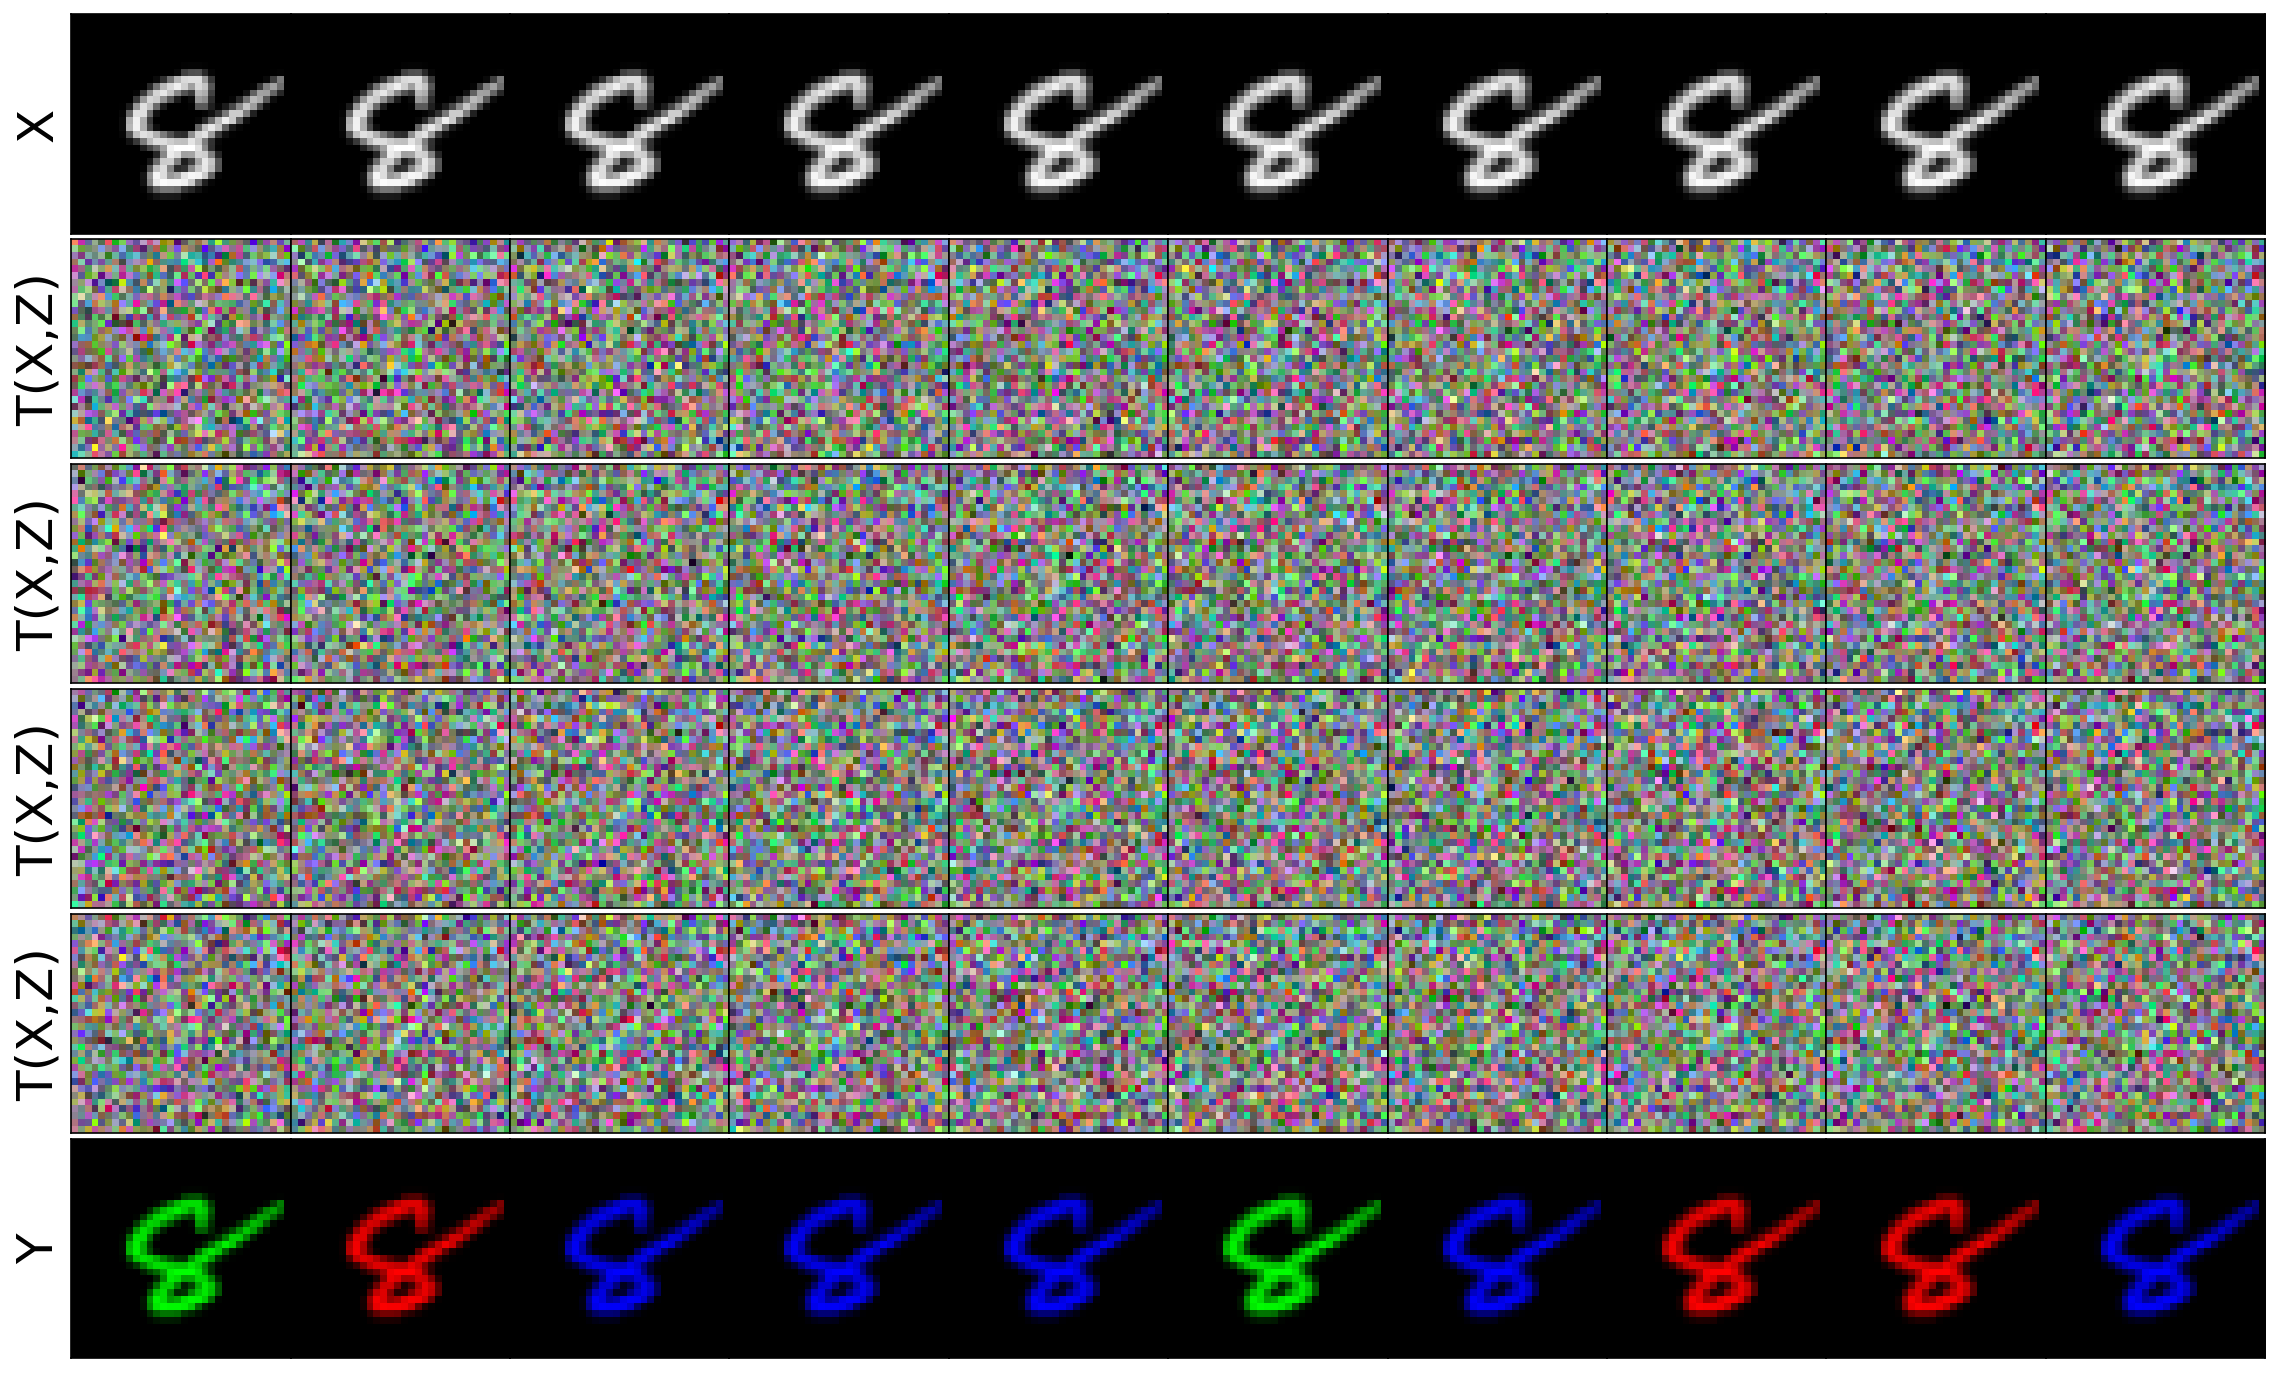

In [9]:
fig, axes = plot_random_Z_images(X_sampler, ZC, Z_STD, Y_sampler, T)

# Run Training

In [10]:
wandb.init(name=EXP_NAME, project="Neural OT", entity='yejun1677-kaist', config=config)
pass

In [11]:
import math
T_opt = torch.optim.SGD(T.parameters(), lr = T_LR)
f_opt = torch.optim.SGD(f.parameters(), lr = f_LR, maximize=True)
# T_opt = torch.optim.Adam(T.parameters(), lr=T_LR, betas=(0.0, 0.9), amsgrad=True)
# f_opt = torch.optim.Adam(f.parameters(), lr=f_LR, betas=(0.0, 0.9), maximize=True, amsgrad=True)
# T_opt_extra = torch.optim.Adam(T.parameters(), lr=T_LR, betas=(0.0, 0.9), amsgrad=True)
# f_opt_extra = torch.optim.Adam(f.parameters(), lr=f_LR, betas=(0.0, 0.9), maximize=True, amsgrad=True)
def get_cosine_lr(step, total_steps, lr_max, lr_min=0.0):
    progress = step / total_steps 
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * progress))

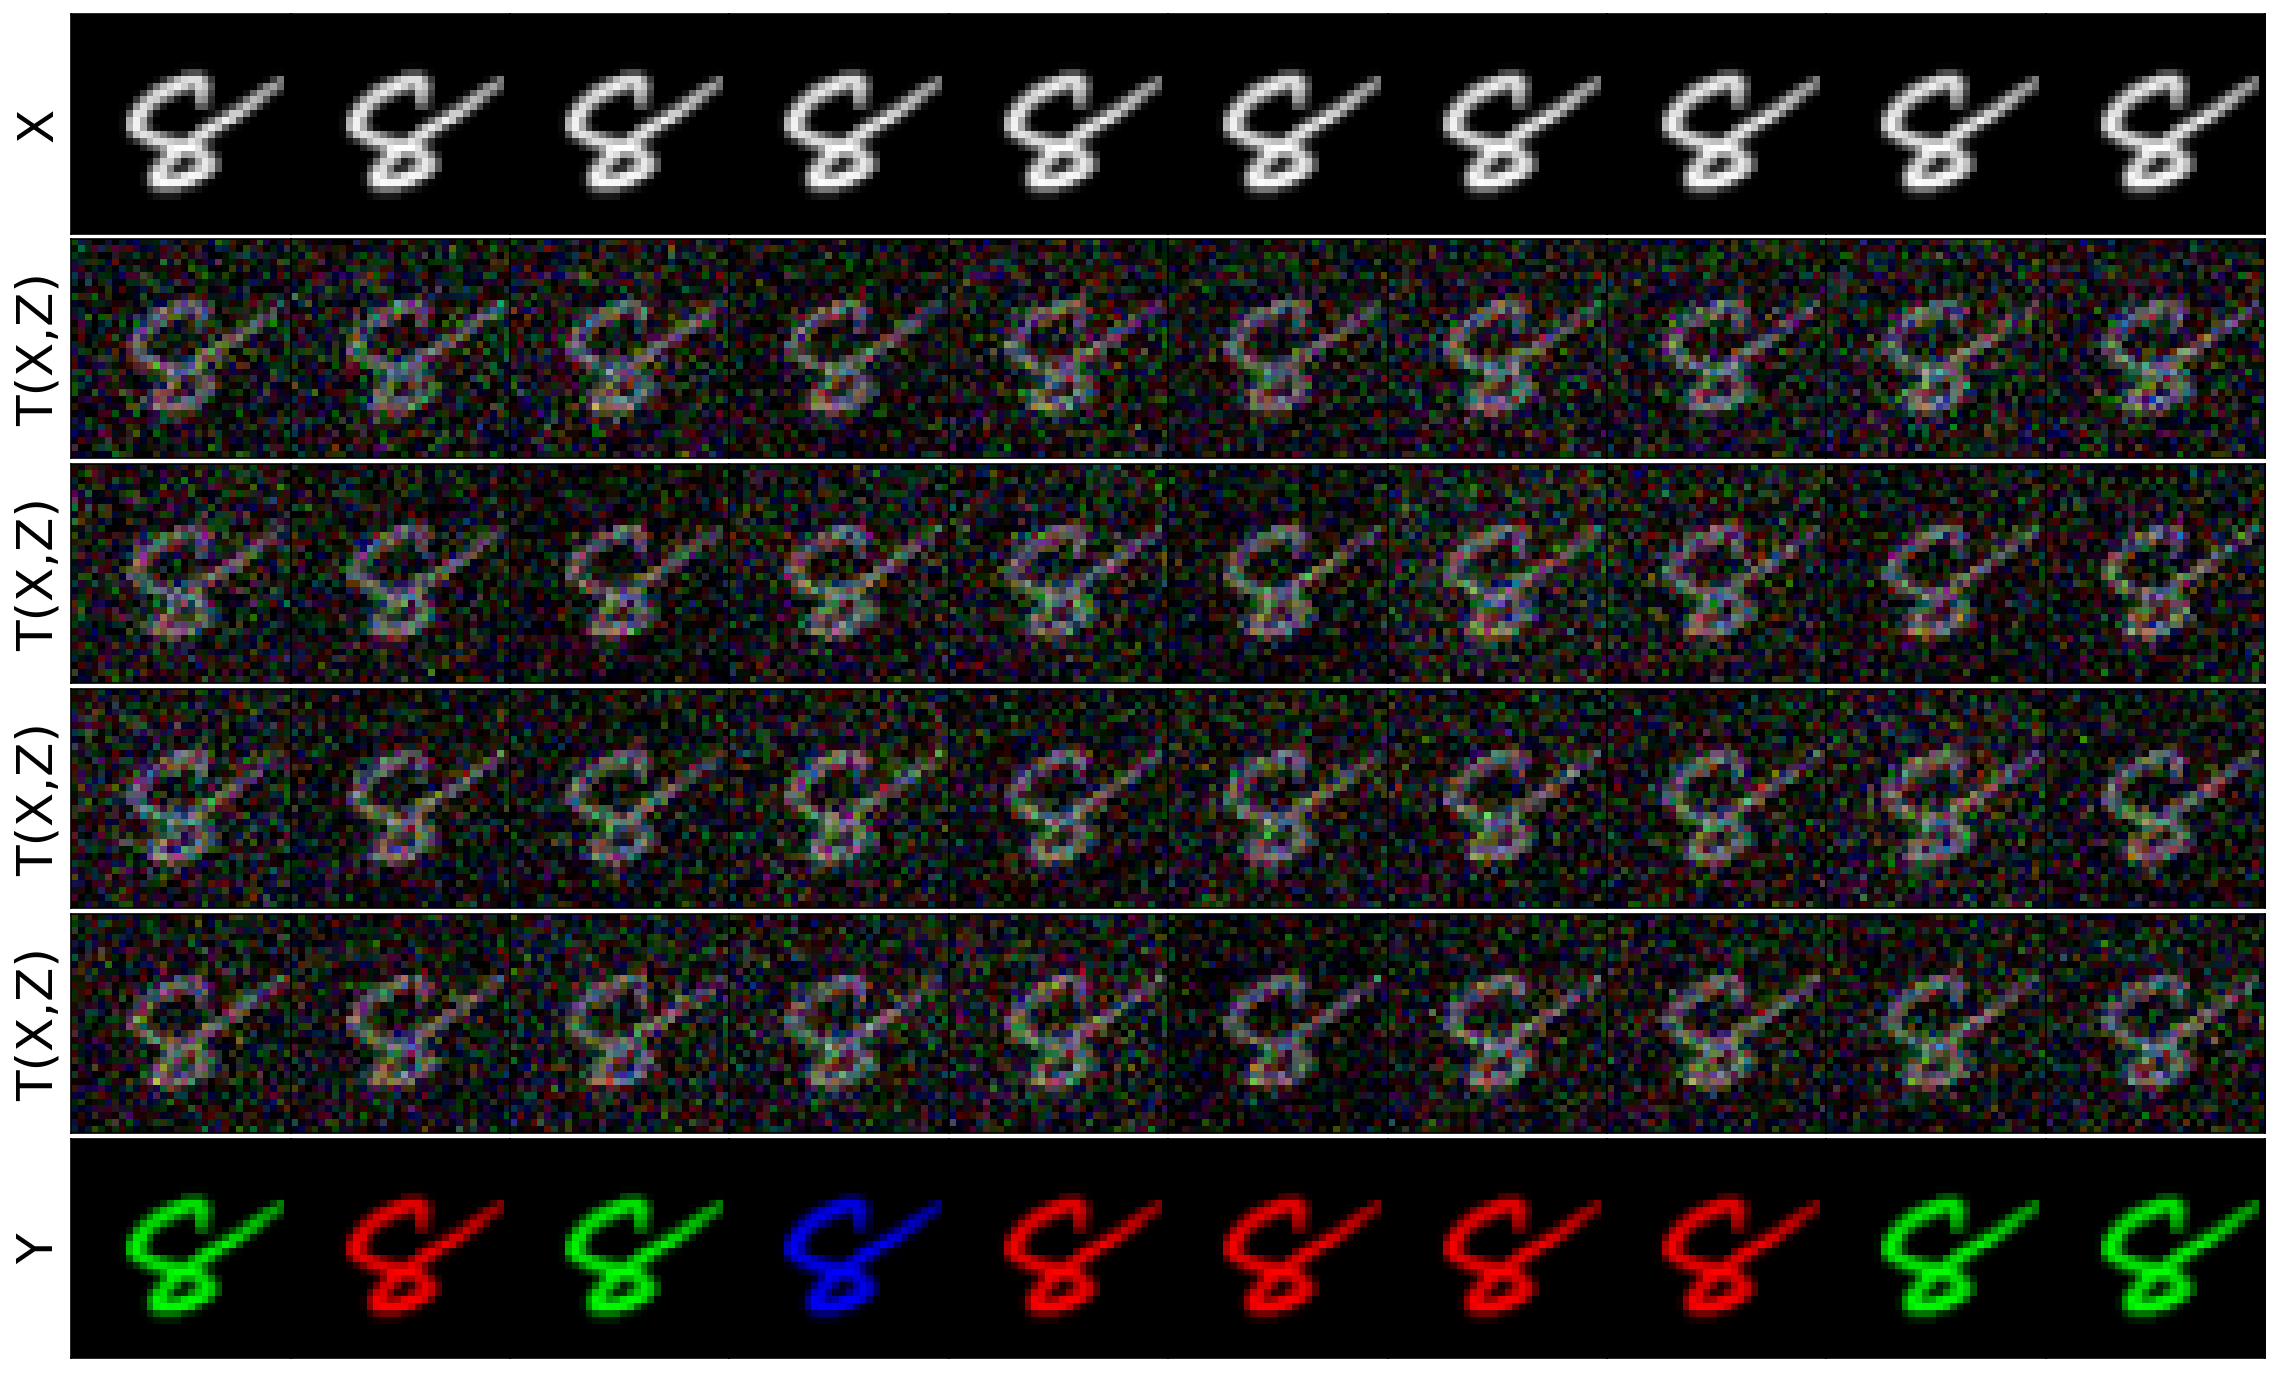

In [ ]:
with torch.no_grad():
    T_buffer = [p.clone().detach() for p in T.parameters()]
    f_buffer = [p.clone().detach() for p in f.parameters()]


for step in tqdm(range(MAX_STEPS)):
    
    if step % 500 == 0:
        gamma = max(0.0, GAMMA0 * (1 - step / GAMMA_ITERS))
        current_T_lr = get_cosine_lr(step, MAX_STEPS, T_LR)
        current_f_lr = get_cosine_lr(step, MAX_STEPS, f_LR)
        
        for param_group in T_opt.param_groups:
            param_group['lr'] = current_T_lr
            
        for param_group in f_opt.param_groups:
            param_group['lr'] = current_f_lr

    for p in T.parameters(): p.requires_grad = True
    for p in f.parameters(): p.requires_grad = True
    
    with torch.no_grad():
        for p, buf in zip(T.parameters(), T_buffer): buf.copy_(p)
        for p, buf in zip(f.parameters(), f_buffer): buf.copy_(p)
    # T_opt_state = deepcopy(T_opt.state_dict())
    # f_opt_state = deepcopy(f_opt.state_dict())

    X = X_sampler.sample(BATCH_SIZE)[:,None].repeat(1,Z_SIZE,1,1,1)
    Y = Y_sampler.sample(BATCH_SIZE*3) 
    
    z_base = torch.randn(BATCH_SIZE, Z_SIZE, ZC, device='cuda') * Z_STD
    Z = z_base.view(BATCH_SIZE, Z_SIZE, ZC, 1, 1).expand(-1, -1, -1, IMG_SIZE, IMG_SIZE)
    # with torch.no_grad():
    #     Z = torch.randn(BATCH_SIZE, Z_SIZE, ZC, IMG_SIZE, IMG_SIZE, device='cuda') * Z_STD
    
    XZ = torch.cat([X, Z], dim=2)
    T_XZ = T(XZ.flatten(start_dim=0, end_dim=1)
        ).permute(1,2,3,0).reshape(3, IMG_SIZE, IMG_SIZE, -1, Z_SIZE).permute(3,4,0,1,2)
        
    loss = F.mse_loss(X, T_XZ).mean() - f(T_XZ.flatten(start_dim=0, end_dim=1)).mean() + f(Y).mean() -  T_XZ.var(dim=1).mean() * gamma



    T_opt.zero_grad(); f_opt.zero_grad()
    loss.backward()
    T_opt.step(); f_opt.step()
    
    del loss, T_XZ

    T_XZ_new = T(XZ.flatten(start_dim=0, end_dim=1)
        ).permute(1,2,3,0).reshape(3, IMG_SIZE, IMG_SIZE, -1, Z_SIZE).permute(3,4,0,1,2)
    loss_new = F.mse_loss(X, T_XZ_new).mean() - f(T_XZ_new.flatten(start_dim=0, end_dim=1)).mean() + f(Y).mean() - T_XZ_new.var(dim=1).mean() * gamma

    T_opt.zero_grad(); f_opt.zero_grad()
    loss_new.backward()

    with torch.no_grad():
        for p, buf in zip(T.parameters(), T_buffer): p.copy_(buf)
        for p, buf in zip(f.parameters(), f_buffer): p.copy_(buf)
    # T_opt.load_state_dict(T_opt_state)
    # f_opt.load_state_dict(f_opt_state)
    
    T_opt.step(); f_opt.step()
    
    wandb.log({f'loss' : loss_new.item()}, step=step)

    del X, Y, Z, XZ, z_base, loss_new, T_XZ_new
        
    if step % PLOT_INTERVAL == 0:
        print('Plotting')
        clear_output(wait=True)
        
        # fig, axes = plot_Z_images(XZ_fixed, Y_fixed, T)
        # wandb.log({'Fixed Images' : [wandb.Image(fig2img(fig))]}, step=step) 
        # plt.show(fig); plt.close(fig) 
        
        fig, axes = plot_random_Z_images(X_sampler, ZC, Z_STD,  Y_sampler, T)
        wandb.log({'Random Images' : [wandb.Image(fig2img(fig))]}, step=step) 
        plt.show(fig); plt.close(fig) 
        
        # fig, axes = plot_Z_images(XZ_test_fixed, Y_test_fixed, T)
        # wandb.log({'Fixed Test Images' : [wandb.Image(fig2img(fig))]}, step=step) 
        # plt.show(fig); plt.close(fig) 
        
        # fig, axes = plot_random_Z_images(X_test_sampler, ZC, Z_STD,  Y_test_sampler, T)
        # wandb.log({'Random Test Images' : [wandb.Image(fig2img(fig))]}, step=step) 
        # plt.show(fig); plt.close(fig) 
        gc.collect(); torch.cuda.empty_cache()
    
#     if step % CPKT_INTERVAL == CPKT_INTERVAL - 1:
#         T.eval(); f.eval()
#         freeze(T); freeze(f)
#         with torch.no_grad():
#             print('Computing FID')
#             mu, sigma = get_Z_pushed_loader_stats(T, X_test_sampler.loader, ZC=ZC, Z_STD=Z_STD)
#             fid = calculate_frechet_distance(mu_data, sigma_data, mu, sigma)
#             wandb.log({f'FID (Test)' : fid}, step=step)
#             del mu, sigma
        
#         torch.save(T.state_dict(), os.path.join(OUTPUT_PATH, f'T_{SEED}_{step}.pt'))
# #         torch.save(f.state_dict(), os.path.join(OUTPUT_PATH, f'f_{SEED}_{step}.pt'))
# #         torch.save(f_opt.state_dict(), os.path.join(OUTPUT_PATH, f'f_opt_{SEED}_{step}.pt'))
# #         torch.save(T_opt.state_dict(), os.path.join(OUTPUT_PATH, f'T_opt_{SEED}_{step}.pt'))
#         unfreeze(T); unfreeze(f)
#         T.train(); f.train()
    